In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

print(df.head())
print("\nDataset shape:", df.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset shape: (20640, 9)


In [3]:
X = df[['AveRooms']].values
y = df['MedHouseVal'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 1)
y shape: (20640,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 16512
Testing samples : 4128


In [5]:
X_mean = X_train.mean()
X_std = X_train.std()

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

print("Mean:", X_mean)
print("Standard deviation:", X_std)

Mean: 5.43523502048753
Standard deviation: 2.387302579723395


In [6]:
X_train_gd = np.c_[
    np.ones((len(X_train_scaled), 1)),
    X_train_scaled
]

X_test_gd = np.c_[
    np.ones((len(X_test_scaled), 1)),
    X_test_scaled
]

print(X_train_gd[:5])

[[ 1.         -0.17491646]
 [ 1.         -0.40283542]
 [ 1.          0.08821601]
 [ 1.         -0.60001532]
 [ 1.          0.3490073 ]]


In [7]:
m = len(X_train_gd)

theta = np.zeros(2)

learning_rate = 0.01
iterations = 1000

cost_history = []

for i in range(iterations):

    predictions = X_train_gd.dot(theta)

    errors = predictions - y_train

    gradients = (2 / m) * X_train_gd.T.dot(errors)

    theta = theta - learning_rate * gradients

    cost = np.mean(errors ** 2)

    cost_history.append(cost)

print("Gradient Descent Parameters:")
print("Intercept:", theta[0])
print("Slope:", theta[1])

Gradient Descent Parameters:
Intercept: 2.071946933891858
Slope: 0.18323881682653


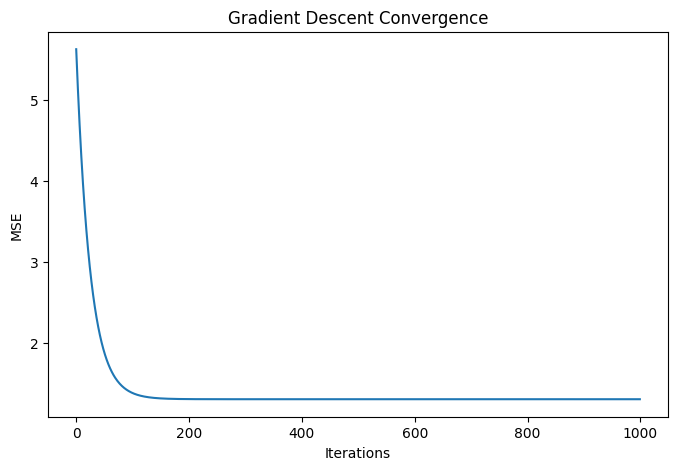

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(cost_history)

plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.title("Gradient Descent Convergence")

plt.show()

In [9]:
y_pred_gd = X_test_gd.dot(theta)

print("First 10 predictions:")
print(y_pred_gd[:10])

First 10 predictions:
[1.97653709 2.04156312 1.96003112 2.12785581 2.07638    2.05784292
 2.13231401 2.03568685 1.95600167 2.18276827]


In [10]:
mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("Gradient Descent Results")
print("-------------------------")
print("MSE:", mse_gd)
print("R-squared:", r2_gd)

Gradient Descent Results
-------------------------
MSE: 1.2923314439327267
R-squared: 0.013795337645229111


In [11]:
X_train_ne = np.c_[
    np.ones((len(X_train_scaled), 1)),
    X_train_scaled
]

X_test_ne = np.c_[
    np.ones((len(X_test_scaled), 1)),
    X_test_scaled
]

theta_ne = np.linalg.inv(
    X_train_ne.T.dot(X_train_ne)
).dot(
    X_train_ne.T.dot(y_train)
)

print("Normal Equation Parameters:")
print("Intercept:", theta_ne[0])
print("Slope:", theta_ne[1])

Normal Equation Parameters:
Intercept: 2.071946937378876
Slope: 0.18323881713491486


In [12]:
y_pred_ne = X_test_ne.dot(theta_ne)

print("First 10 predictions:")
print(y_pred_ne[:10])

First 10 predictions:
[1.97653709 2.04156313 1.96003112 2.12785581 2.07638001 2.05784293
 2.13231401 2.03568685 1.95600167 2.18276827]


In [13]:
mse_ne = mean_squared_error(y_test, y_pred_ne)
r2_ne = r2_score(y_test, y_pred_ne)

print("Normal Equation Results")
print("-----------------------")
print("MSE:", mse_ne)
print("R-squared:", r2_ne)

Normal Equation Results
-----------------------
MSE: 1.2923314440807299
R-squared: 0.013795337532284901


In [14]:
comparison = pd.DataFrame({
    "Method": ["Gradient Descent", "Normal Equation"],
    "MSE": [mse_gd, mse_ne],
    "R-squared": [r2_gd, r2_ne]
})

print(comparison)

             Method       MSE  R-squared
0  Gradient Descent  1.292331   0.013795
1   Normal Equation  1.292331   0.013795


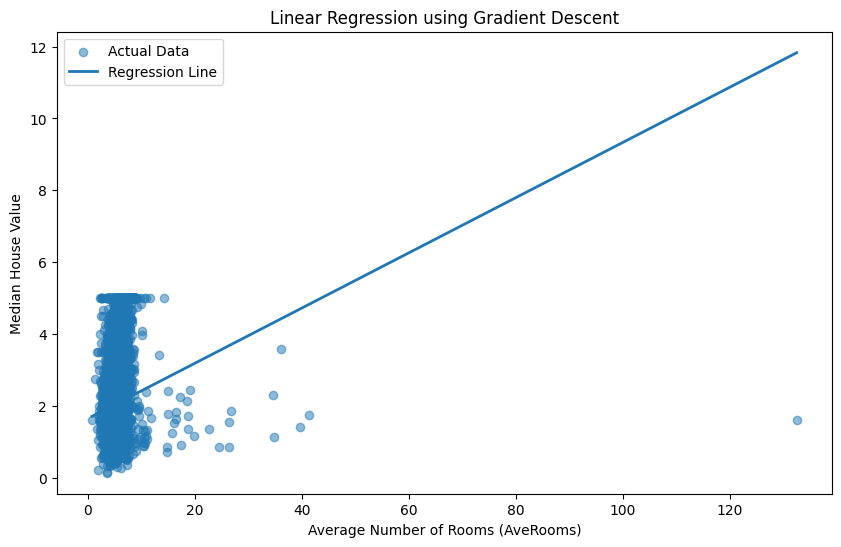

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test,
    y_test,
    alpha=0.5,
    label="Actual Data"
)

# Sort X values for a smooth line
sort_index = np.argsort(X_test[:, 0])

X_sorted = X_test[sort_index]
X_sorted_scaled = (X_sorted - X_mean) / X_std

X_sorted_gd = np.c_[
    np.ones((len(X_sorted_scaled), 1)),
    X_sorted_scaled
]

y_line = X_sorted_gd.dot(theta)

plt.plot(
    X_sorted,
    y_line,
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Average Number of Rooms (AveRooms)")
plt.ylabel("Median House Value")
plt.title("Linear Regression using Gradient Descent")

plt.legend()
plt.show()

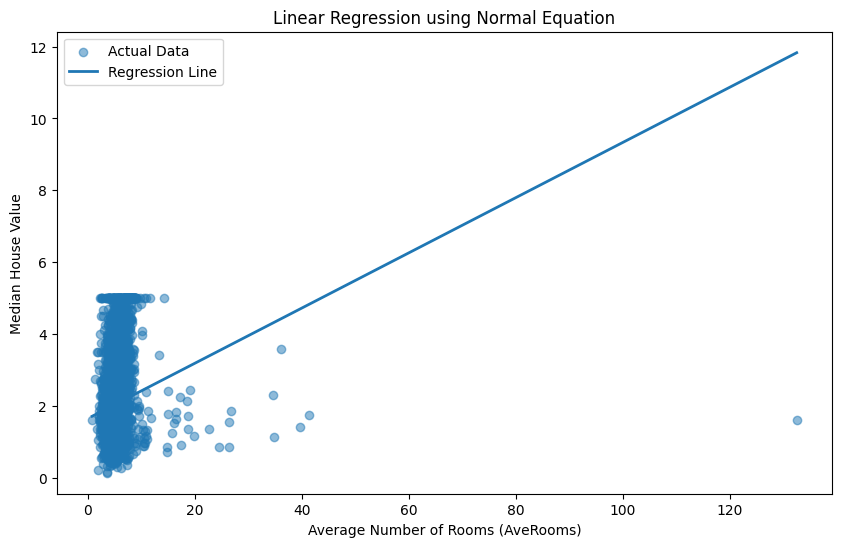

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test,
    y_test,
    alpha=0.5,
    label="Actual Data"
)

X_sorted_ne = np.c_[
    np.ones((len(X_sorted_scaled), 1)),
    X_sorted_scaled
]

y_line_ne = X_sorted_ne.dot(theta_ne)

plt.plot(
    X_sorted,
    y_line_ne,
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Average Number of Rooms (AveRooms)")
plt.ylabel("Median House Value")
plt.title("Linear Regression using Normal Equation")

plt.legend()
plt.show()

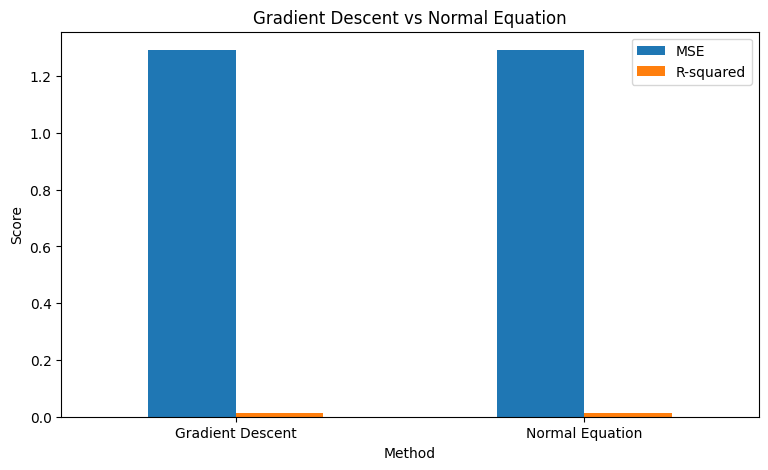

In [17]:
comparison.set_index("Method")[["MSE", "R-squared"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Gradient Descent vs Normal Equation")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()

plt.show()